# Feature engineering — preparando informações para prever preços

**Moeda adotada:** dólar americano (USD), por premissa do projeto baseada no contexto de Seattle. Não houve conversão cambial nem alteração dos valores. A fonte não confirmou explicitamente a moeda. Preços e erros monetários estão em USD; percentuais, R² e contribuições SHAP em log mantêm suas próprias escalas.

## Objetivo
Criar e documentar variáveis candidatas a partir das características dos imóveis, aplicando as mesmas regras ao histórico e aos exemplos futuros. Verificar ordem, tipos, ausências e casos especiais antes da modelagem.

**Fluxo:** EDA geral → merge e EDA complementar → **preparação das variáveis** → split e modelagem. Nesta etapa não treinamos modelos nem separamos os dados.

Feature engineering significa transformar informações existentes em representações que podem ajudar o modelo. Uma variável nova é uma candidata, não uma melhoria comprovada. Seu benefício será avaliado na validação.

Faremos apenas transformações que usam os valores da própria linha, sem aprender médias, limites de outliers ou categorias do histórico inteiro. Imputação, normalização, codificação de CEP e seleção de variáveis serão ajustadas dentro de cada treino após o split.

**Execução:** selecione o Python da `.venv` e execute em ordem. O notebook lê os dois CSVs do merge em `data/processed/`, preserva esses arquivos e gera novas tabelas de entradas e um contrato de colunas. As hipóteses de significado das colunas continuam sujeitas à confirmação.

**Convenção de nomes:** todas as colunas de entrada do modelo, originais e derivadas, usam nomes em inglês. Variáveis e funções Python, comentários e explicações permanecem em português. Tabelas de diagnóstico usam rótulos de apresentação em português.


In [1]:
# Carrega os dados combinados e prepara os caminhos de saída.
from pathlib import Path
import hashlib
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display as exibir

PASTA_PROJETO = Path.cwd()
if not (PASTA_PROJETO / "data" / "processed").is_dir():
    PASTA_PROJETO = PASTA_PROJETO.parent
PASTA_DADOS = PASTA_PROJETO / "data" / "processed"
PASTA_RESULTADOS = PASTA_PROJETO / "reports" / "metrics"
PASTA_GRAFICOS = PASTA_PROJETO / "reports" / "figures"
for pasta in [PASTA_RESULTADOS, PASTA_GRAFICOS]:
    pasta.mkdir(parents=True, exist_ok=True)

historico = pd.read_csv(PASTA_DADOS / "imoveis_com_demografia.csv",
                       dtype={"id": "string", "zipcode": "string"})
futuros = pd.read_csv(PASTA_DADOS / "futuros_com_demografia.csv",
                     dtype={"zipcode": "string"})
colunas_fisicas = pd.read_csv(
    PASTA_PROJETO / "data" / "raw" / "future_unseen_examples.csv", nrows=0
).columns.tolist()
exibir(pd.DataFrame([
    {"arquivo": "histórico após merge", "linhas": len(historico), "colunas": historico.shape[1]},
    {"arquivo": "futuros após merge", "linhas": len(futuros), "colunas": futuros.shape[1]},
]))

,arquivo,linhas,colunas
0,histórico após merge,21613,47
1,futuros após merge,100,44


**O que o resultado mostra**

O histórico tem 21.613 linhas e 47 colunas; os exemplos futuros têm 100 linhas e 44 colunas. A diferença corresponde a identificador, data e preço.

**Por que fizemos esta análise e o que decidimos**

Reutilizamos o merge validado, sem refazer a junção ou depender de variáveis de outro notebook. Os exemplos futuros continuam separados e não participam de treinamento ou escolha de tratamentos.

## 1. Separando as entradas do preço e das informações de identificação

`price` é a resposta que o modelo aprenderá a prever, não uma entrada. `id` e `date` serão guardados para rastrear vendas e definir o split na etapa 4. Como não existem no arquivo futuro, não serão usados para criar variáveis de previsão.

In [2]:
# Define a ordem das entradas e guarda preço, ID e data separadamente.
colunas_entrada = [coluna for coluna in historico.columns if coluna not in ["id", "date", "price"]]
if not (historico.columns.is_unique and futuros.columns.is_unique):
    raise ValueError('Foram encontradas duplicidades onde registros ou nomes deveriam ser únicos.')
if set(colunas_entrada) != set(futuros.columns):
    raise ValueError("Investigar diferença de colunas.")
ordem_original_igual = colunas_entrada == futuros.columns.tolist()

entradas_historico = historico.loc[:, colunas_entrada].copy()
entradas_futuras = futuros.loc[:, colunas_entrada].copy()
identificacao_alvo = historico.loc[:, ["id", "date", "price"]].copy()
identificacao_alvo.insert(0, "linha_origem", np.arange(len(historico)))
colunas_demograficas = [coluna for coluna in colunas_entrada if coluna not in colunas_fisicas]

exibir(pd.DataFrame({
    "verificacao": ["Ordem original já igual", "Entradas físicas", "Indicadores demográficos",
                    "Entradas totais antes da criação"],
    "resultado": [ordem_original_igual, len(colunas_fisicas), len(colunas_demograficas), len(colunas_entrada)],
}))

,verificacao,resultado
0,Ordem original já igual,True
1,Entradas físicas,18
2,Indicadores demográficos,26
3,Entradas totais antes da criação,44


**O que o resultado mostra**

As 44 entradas têm a mesma ordem nos dois arquivos: 18 características físicas e 26 indicadores demográficos. Mesmo assim, o código seleciona explicitamente a ordem definida pelo histórico.

**Por que fizemos esta análise e o que decidimos**

Isso evita depender da posição em que um CSV foi montado. O preço fica em uma tabela separada, junto com ID, data e número da linha original. Nenhuma variável será construída a partir de preços ou de medianas de preços por CEP.

## 2. Decisões sobre dados incomuns e significados ainda incertos

Os outliers da EDA não foram classificados como erros comprovados. Nesta versão, preservaremos preços, áreas, quartos e anos originais. Não trocaremos 33 quartos por 3 e não apagaremos imóveis caros. Variáveis derivadas usarão proteções locais para não gerar divisão por zero ou logaritmos inválidos.

In [3]:
# Conta casos que exigem cuidado sem mudar os valores originais.
diagnostico_preparacao = []
for nome, tabela in {"historico": entradas_historico, "futuros": entradas_futuras}.items():
    diagnostico_preparacao.append({
        "arquivo": nome,
        "quartos_zero": int(tabela["bedrooms"].eq(0).sum()),
        "banheiros_zero": int(tabela["bathrooms"].eq(0).sum()),
        "registros_33_quartos": int(tabela["bedrooms"].eq(33).sum()),
        "reforma_igual_zero": int(tabela["yr_renovated"].eq(0).sum()),
        "ausencias_originais": int(tabela.isna().sum().sum()),
    })
diagnostico_preparacao = pd.DataFrame(diagnostico_preparacao)
diagnostico_preparacao.to_csv(PASTA_RESULTADOS / "features_diagnostico.csv", index=False)
exibir(diagnostico_preparacao)

,arquivo,quartos_zero,banheiros_zero,registros_33_quartos,reforma_igual_zero,ausencias_originais
0,historico,13,10,1,20699,0
1,futuros,0,0,0,97,0


**O que o resultado mostra**

No histórico, há 13 registros com zero quartos, 10 com zero banheiros e um registro com 33 quartos. A tabela também mostra esses casos nos exemplos futuros e a quantidade de anos de reforma iguais a zero.

**Por que fizemos esta análise e o que decidimos**

Zero quartos não será usado como denominador. O ano zero será interpretado apenas como ausência de um ano positivo registrado ao criar um indicador; não prova que nunca houve reforma. Anos posteriores à venda exigem investigação, mas não podemos aplicar uma regra baseada na data de venda aos futuros, que não têm essa coluna.

**Hipótese**

Outliers plausíveis podem ser representados por modelos flexíveis ou transformações de escala. Compararemos alternativas na validação, preservando uma referência sem remoções automáticas.

In [4]:
# Documenta cada candidata antes de implementá-la.
catalogo_variaveis = pd.DataFrame([
    ["has_recorded_basement", "sqft_basement", "1 se área do porão > 0; 0 se = 0", "Separar presença de porão de seu tamanho."],
    ["has_renovation_year", "yr_renovated", "1 se há ano positivo; 0 se = 0", "Separar ano registrado da ausência de ano positivo."],
    ["basement_area_ratio", "sqft_basement / sqft_living", "Dividir apenas com área habitável > 0", "Descrever a participação do porão na área."],
    ["living_area_per_bedroom", "sqft_living / bedrooms", "Dividir apenas com quartos > 0", "Relacionar espaço e quantidade de quartos."],
    ["bathrooms_per_bedroom", "bathrooms / bedrooms", "Dividir apenas com quartos > 0", "Representar a relação entre as duas contagens."],
    ["log_living_area", "sqft_living", "log(1 + área), se não negativa", "Comprimir diferenças entre áreas muito grandes."],
    ["log_lot_area", "sqft_lot", "log(1 + área), se não negativa", "Comprimir a longa extensão dos tamanhos de terreno."],
], columns=["variavel", "origem", "regra", "motivo"])
novas_colunas = catalogo_variaveis["variavel"].tolist()
# Exibe todas as colunas sem cortar o conteúdo das células
catalogo_variaveis.to_csv(PASTA_RESULTADOS / "features_catalogo.csv", index=False)
with pd.option_context(
    "display.max_colwidth", None,
    "display.max_columns", None,
):
    exibir(catalogo_variaveis)

,variavel,origem,regra,motivo
0,has_recorded_basement,sqft_basement,1 se área do porão > 0; 0 se = 0,Separar presença de porão de seu tamanho.
1,has_renovation_year,yr_renovated,1 se há ano positivo; 0 se = 0,Separar ano registrado da ausência de ano positivo.
2,basement_area_ratio,sqft_basement / sqft_living,Dividir apenas com área habitável > 0,Descrever a participação do porão na área.
3,living_area_per_bedroom,sqft_living / bedrooms,Dividir apenas com quartos > 0,Relacionar espaço e quantidade de quartos.
4,bathrooms_per_bedroom,bathrooms / bedrooms,Dividir apenas com quartos > 0,Representar a relação entre as duas contagens.
5,log_living_area,sqft_living,"log(1 + área), se não negativa",Comprimir diferenças entre áreas muito grandes.
6,log_lot_area,sqft_lot,"log(1 + área), se não negativa",Comprimir a longa extensão dos tamanhos de terreno.


| Variável candidata | Tradução | O que representa |
|---|---|---|
| `has_recorded_basement` | Possui porão registrado | Indica se a área de porão informada é maior que zero. |
| `has_renovation_year` | Possui ano de reforma informado | Indica se existe um ano de reforma positivo registrado. |
| `basement_area_ratio` | Proporção da área do porão | Área do porão dividida pela área habitável. |
| `living_area_per_bedroom` | Área habitável por quarto | Área habitável total dividida pela quantidade de quartos; não é a área física de cada quarto. |
| `bathrooms_per_bedroom` | Banheiros por quarto | Quantidade de banheiros dividida pela quantidade de quartos. |
| `log_living_area` | Logaritmo da área habitável | `log(1 + área habitável)`, usado para comprimir diferenças entre valores elevados. |
| `log_lot_area` | Logaritmo da área do terreno | `log(1 + área do terreno)`, usado para comprimir diferenças entre valores elevados. |

**O que o resultado mostra**

Foram propostas sete variáveis. Todas podem ser calculadas a partir das informações disponíveis também no dataset futuros_com_demografia, sem usar preço, ID ou data.

**Por que fizemos esta análise e o que decidimos**

Não calculamos idade usando o ano atual, porque isso faria a entrada mudar conforme o dia de execução e não resolveria a ausência de data nos futuros. Também não atribuímos significado ao sufixo `15`. Mantemos as colunas originais para comparar conjuntos de variáveis candidatas.

**Hipótese**

Relações entre áreas e contagens podem facilitar a representação de perfis de imóveis. Porém, podem repetir informação já acessível ao modelo e não garantir melhora.

## 3. Uma mesma função para histórico e previsão

A função é independente das outras linhas: transformar uma casa sozinha ou junto com outras deve produzir o mesmo resultado. Ela não aprende estatísticas e pode ser executada antes do split. Valores ausentes continuam ausentes; denominadores inválidos produzem ausência na variável derivada, e não um número inventado.

In [5]:
# Cria candidatas usando somente os valores da própria linha.
def criar_variaveis(tabela):
    if not (tabela.columns.is_unique):
        raise ValueError("Existem nomes de colunas duplicados.")
    faltantes = sorted(set(colunas_entrada) - set(tabela.columns))
    if faltantes:
        raise ValueError(f"Colunas obrigatórias ausentes: {faltantes}")
    resultado = tabela.loc[:, colunas_entrada].copy()
    resultado["zipcode"] = resultado["zipcode"].astype("string").str.strip()

    # Preserva ausência ou valores negativos nos indicadores derivados.
    resultado["has_recorded_basement"] = (
        resultado["sqft_basement"].gt(0).astype(float)
        .where(resultado["sqft_basement"].ge(0))
    )
    resultado["has_renovation_year"] = (
        resultado["yr_renovated"].gt(0).astype(float)
        .where(resultado["yr_renovated"].ge(0))
    )

    # Só divide quando os denominadores são positivos.
    area_valida = resultado["sqft_living"].where(resultado["sqft_living"].gt(0))
    quartos_validos = resultado["bedrooms"].where(resultado["bedrooms"].gt(0))
    resultado["basement_area_ratio"] = resultado["sqft_basement"].where(resultado["sqft_basement"].ge(0)) / area_valida
    resultado["living_area_per_bedroom"] = resultado["sqft_living"].where(resultado["sqft_living"].ge(0)) / quartos_validos
    resultado["bathrooms_per_bedroom"] = resultado["bathrooms"].where(resultado["bathrooms"].ge(0)) / quartos_validos

    # A transformação logarítmica não altera as áreas originais.
    resultado["log_living_area"] = np.log1p(resultado["sqft_living"].where(resultado["sqft_living"].ge(0)))
    resultado["log_lot_area"] = np.log1p(resultado["sqft_lot"].where(resultado["sqft_lot"].ge(0)))
    # As colunas originais vêm primeiro; as derivadas seguem a ordem de criação.
    return resultado

variaveis_historico = criar_variaveis(entradas_historico)
variaveis_futuras = criar_variaveis(entradas_futuras)

# Atualiza os nomes a partir das colunas criadas, sem reutilizar uma lista antiga.
novas_colunas = [coluna for coluna in variaveis_historico.columns if coluna not in colunas_entrada]
pd.testing.assert_frame_equal(variaveis_historico[colunas_entrada], entradas_historico)
pd.testing.assert_frame_equal(variaveis_futuras[colunas_entrada], entradas_futuras)
exibir(variaveis_historico[["bedrooms", "sqft_living", "sqft_basement"] + novas_colunas].head(8))

,bedrooms,sqft_living,sqft_basement,has_recorded_basement,has_renovation_year,basement_area_ratio,living_area_per_bedroom,bathrooms_per_bedroom,log_living_area,log_lot_area
0,3,1180,0,0.0,0.0,0.000000,393.333333,0.333333,7.074117,8.639588
1,3,2570,400,1.0,1.0,0.155642,856.666667,0.750000,7.852050,8.887791
2,2,770,0,0.0,0.0,0.000000,385.000000,0.500000,6.647688,9.210440
3,4,1960,910,1.0,0.0,0.464286,490.000000,0.750000,7.581210,8.517393
4,3,1680,0,0.0,0.0,0.000000,560.000000,0.666667,7.427144,8.997271
5,4,5420,1530,1.0,0.0,0.282288,1355.000000,1.125000,8.598036,11.532051
6,3,1715,0,0.0,0.0,0.000000,571.666667,0.750000,7.447751,8.827615
7,3,1060,0,0.0,0.0,0.000000,353.333333,0.500000,6.966967,9.181118


**O que o resultado mostra**

A tabela ilustra as sete variáveis candidatas ao lado dos dados de origem. Os dois conjuntos agora têm 51 entradas, na mesma ordem, e todas as linhas e colunas originais foram preservadas.

**Por que fizemos esta análise e o que decidimos**

O uso de uma única função evita regras diferentes no treino e na previsão. `living_area_per_bedroom` não é a área real de cada quarto: é a área habitável total dividida pela quantidade de quartos. `basement_area_ratio` só tem esse significado se as definições das áreas forem compatíveis.

**Hipótese**

Indicadores de presença podem permitir distinguir casas com e sem porão ou ano de reforma informado, enquanto as medidas contínuas descrevem tamanho e época. Essa utilidade precisa ser medida na validação.

In [6]:
# Confere ausências e valores não finitos gerados pelas transformações.
relatorio_ausencias = pd.DataFrame({
    "ausencias_historico": variaveis_historico[novas_colunas].isna().sum(),
    "ausencias_futuros": variaveis_futuras[novas_colunas].isna().sum(),
}).rename_axis("variavel")
for tabela in [variaveis_historico, variaveis_futuras]:
    if np.isinf(tabela.select_dtypes(include='number').to_numpy()).any():
        raise ValueError('Foram encontrados valores inválidos. Confira ausências, infinitos e limites antes de continuar.')
relatorio_ausencias.to_csv(PASTA_RESULTADOS / "features_ausencias.csv")
exibir(relatorio_ausencias)

,ausencias_historico,ausencias_futuros
variavel,,
has_recorded_basement,0,0
has_renovation_year,0,0
basement_area_ratio,0,0
living_area_per_bedroom,13,0
bathrooms_per_bedroom,13,0
log_living_area,0,0
log_lot_area,0,0


**O que o resultado mostra**

No histórico, as 13 linhas com zero quartos recebem ausência em `living_area_per_bedroom` e `bathrooms_per_bedroom`, porque a divisão não tem significado. Isso não apaga a linha nem altera a quantidade original de quartos. As verificações rejeitam valores infinitos.

**Por que fizemos esta análise e o que decidimos**

Não substituímos zero quartos por um nem preenchemos a razão com a média do histórico. O preenchimento será aprendido somente no treino. A tabela informa quais variáveis precisarão desse tratamento e permite conferir o comportamento dos futuros.

**Hipótese**

Um indicador de ausência, criado no pipeline após o split, pode ajudar a distinguir situações sem razão calculável. Seu benefício deverá ser comparado com um tratamento simples de imputação.

## 4. Como ficaram as novas representações?

Os gráficos abaixo descrevem o histórico completo. Eles ajudam a conferir o cálculo e levantar hipóteses, mas não medem desempenho. Não faremos seleção automática de variáveis candidatas pela associação com preço nesta etapa.

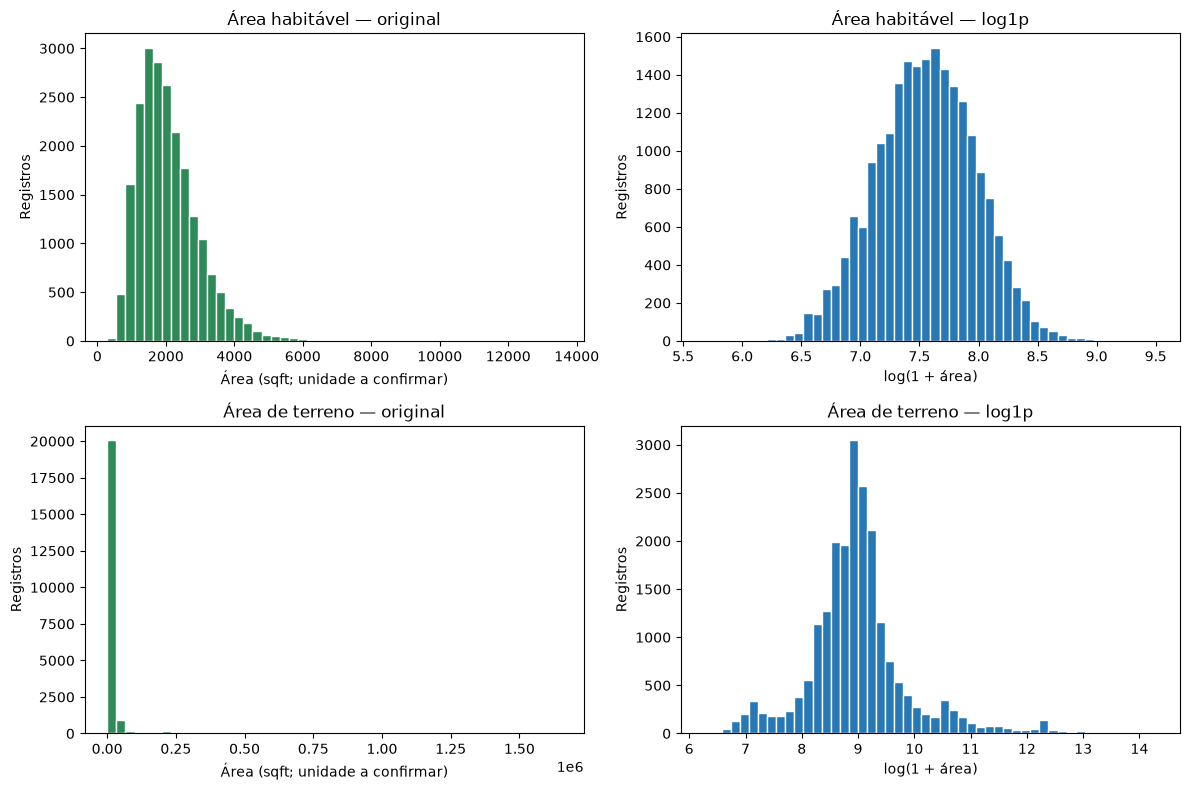

In [7]:
# Compara áreas originais e suas versões logarítmicas.
figura, eixos = plt.subplots(2, 2, figsize=(12, 8))
comparacoes = [
    ("sqft_living", "Área habitável", "log_living_area"),
    ("sqft_lot", "Área de terreno", "log_lot_area"),
]
for linha, (original, titulo, transformada) in enumerate(comparacoes):
    eixos[linha, 0].hist(variaveis_historico[original], bins=50, color="#2E8B57", edgecolor="white")
    eixos[linha, 0].set(title=titulo + " — original", xlabel="Área (sqft; unidade a confirmar)", ylabel="Registros")
    eixos[linha, 1].hist(variaveis_historico[transformada], bins=50, color="#2878B5", edgecolor="white")
    eixos[linha, 1].set(title=titulo + " — log1p", xlabel="log(1 + área)", ylabel="Registros")
for eixo in eixos.flat:
    eixo.grid(False)
figura.tight_layout()
figura.savefig(PASTA_GRAFICOS / "features_areas_log.png", dpi=150)
plt.show()

**O que o resultado mostra**

As versões logarítmicas comprimem as diferenças entre áreas elevadas. Os mesmos imóveis estão nas duas representações; nenhuma casa grande foi removida. Os eixos e as faixas das barras mudam, portanto suas alturas não devem ser comparadas barra a barra.

**Por que fizemos esta análise e o que decidimos**

É uma transformação da variável explicativa, não do preço. As áreas originais continuam disponíveis. Um gráfico mais equilibrado não comprova normalidade nem melhora preditiva; a escolha entre áreas originais e transformadas dependerá da validação.

**Hipótese**

Uma escala comprimida pode facilitar relações para um modelo linear. Para modelos de árvores, o benefício pode ser pequeno, pois a ordenação dos valores é preservada.

In [8]:
# Resume as razões criadas, sem confundir razões com medidas físicas diretas.
resumo_derivadas = variaveis_historico[
    ["basement_area_ratio", "living_area_per_bedroom", "bathrooms_per_bedroom"]
].describe(percentiles=[0.5, 0.95, 0.99]).T
resumo_derivadas.to_csv(PASTA_RESULTADOS / "features_resumo_derivadas.csv")
exibir(resumo_derivadas)

,count,mean,std,min,50%,95%,99%,max
basement_area_ratio,21613.0,0.124502,0.170969,0.000000,0.000000,0.465989,0.50,0.666667
living_area_per_bedroom,21600.0,618.152810,215.884916,49.090909,576.666667,1023.416667,1317.50,3420.000000
bathrooms_per_bedroom,21600.0,0.640880,0.211771,0.000000,0.625000,1.000000,1.25,2.500000


**O que o resultado mostra**

A mediana de área por quarto é aproximadamente 576,67 e a de banheiros por quarto é 0,625, considerando 21.600 valores calculáveis em cada razão. A proporção mediana de porão é zero e seu máximo é aproximadamente 0,667. A tabela mostra também a dispersão e os extremos. `50%` é a mediana; `95%` e `99%` marcam valores abaixo dos quais ficam aproximadamente essas proporções das observações válidas. Linhas sem quartos não entram no resumo dessas duas razões.

**Por que fizemos esta análise e o que decidimos**

Razões também podem produzir extremos. Um valor grande de área por quarto pode refletir casa espaçosa, poucos quartos ou cadastro incorreto; não é motivo automático de remoção. Proporção de porão deve ser interpretada junto com as definições de área.

**Hipótese**

Representar as características em relação umas às outras pode destacar diferenças de configuração que contagens isoladas não evidenciam. O registro com 33 quartos continuará exigindo revisão, mesmo que sua razão pareça numericamente válida.

## 5. Conferindo casos que podem aparecer na previsão

Vamos testar cópias separadas para verificar o cálculo. Elas não serão adicionadas ao histórico nem ao arquivo futuro. O objetivo é conferir ausência, divisão inválida, mudança na ordem de colunas e independência em relação a outras linhas.

In [9]:
# Verifica que a função não depende da ordem recebida ou de outras casas.
pd.testing.assert_frame_equal(
    criar_variaveis(entradas_futuras.iloc[:1]),
    variaveis_futuras.iloc[:1],
)
pd.testing.assert_frame_equal(
    criar_variaveis(entradas_futuras.loc[:, colunas_entrada[::-1]]),
    variaveis_futuras,
)

# Simula ausência regional e denominadores inválidos numa cópia.
caso_simulado = entradas_futuras.head(1).copy()
caso_simulado["bedrooms"] = 0
caso_simulado["sqft_living"] = 0
caso_simulado["sqft_lot"] = -1
caso_simulado["sqft_basement"] = np.nan
caso_simulado[colunas_demograficas] = np.nan
caso_simulado["zipcode"] = pd.Series(["00000"], index=caso_simulado.index, dtype="string")
resultado_simulado = criar_variaveis(caso_simulado)
assert resultado_simulado[["living_area_per_bedroom", "bathrooms_per_bedroom",
                          "basement_area_ratio", "log_lot_area", "has_recorded_basement"]].isna().all().all()
assert resultado_simulado[colunas_demograficas].isna().all().all()
assert resultado_simulado["zipcode"].iloc[0] == "00000"

# Uma coluna obrigatória ausente precisa ser identificada claramente.
try:
    criar_variaveis(entradas_futuras.drop(columns="bedrooms"))
except ValueError as erro:
    assert "bedrooms" in str(erro)
else:
    raise AssertionError("A ausência de uma coluna obrigatória deveria interromper a função.")

exibir(pd.DataFrame({
    "verificacao": ["Mesma casa sozinha ou em lote", "Ordem de colunas invertida",
                    "Divisões inválidas e áreas negativas", "CEPs e indicadores desconhecidos",
                    "Coluna obrigatória ausente"],
    "resultado": ["mesmas variáveis", "ordem restaurada", "ausência na derivada",
                  "valores preservados sem inventar indicadores", "erro claro identificado"],
}))

,verificacao,resultado
0,Mesma casa sozinha ou em lote,mesmas variáveis
1,Ordem de colunas invertida,ordem restaurada
2,Divisões inválidas e áreas negativas,ausência na derivada
3,CEPs e indicadores desconhecidos,valores preservados sem inventar indicadores
4,Coluna obrigatória ausente,erro claro identificado


**O que o resultado mostra**

As verificações confirmam que a mesma casa recebe as mesmas variáveis sozinha ou em lote e que colunas invertidas são reorganizadas. Na simulação, denominadores inválidos e indicadores ausentes não geram infinitos nem valores preenchidos arbitrariamente.

**Por que fizemos esta análise e o que decidimos**

A função prepara as entradas, mas ainda não garante que um modelo consiga prever casos com ausências. O pipeline da modelagem deverá imputar números e lidar com CEP desconhecido. Os casos simulados são separados e não entram na exportação.

## 6. O que será ajustado somente depois do split?

O pipeline completo ainda não está treinado. Esta etapa fornece apenas o bloco de criação de variáveis candidatas. A sequência de modelagem será: criar variáveis por linha → selecionar e ordenar as colunas do candidato → preencher ausências → codificar categorias e, quando necessário, normalizar → treinar o modelo.

In [10]:
# Registra quais etapas podem ser executadas agora e quais aprendem no treino.
plano_pipeline = pd.DataFrame([
    ["Criação das sete candidatas", "implementada", "Usa apenas valores da própria linha"],
    ["Seleção do conjunto de colunas", "definir/comparar na modelagem", "Salvar nomes e ordem do conjunto escolhido"],
    ["Preenchimento de números ausentes", "ajustar em cada treino", "Aprender medianas sem consultar validação ou teste"],
    ["Codificação do CEP", "ajustar em cada treino", "Tratar categorias desconhecidas sem erro"],
    ["Normalização para regressão linear/Ridge", "ajustar em cada treino", "Aprender média e escala somente do treino"],
    ["Limites para tratamento de outliers", "candidatos a avaliar", "Aprender limites no treino; manter referência sem corte"],
    ["Transformação do preço em log", "candidata a avaliar", "Reverter previsões e medir erros na escala original"],
], columns=["etapa", "situacao", "regra"])
plano_pipeline.to_csv(PASTA_RESULTADOS / "features_plano_pipeline.csv", index=False)
# Exibe todas as colunas sem cortar o conteúdo das células.
with pd.option_context(
    "display.max_colwidth", None,
    "display.max_columns", None,
):
    exibir(plano_pipeline)

,etapa,situacao,regra
0,Criação das sete candidatas,implementada,Usa apenas valores da própria linha
1,Seleção do conjunto de colunas,definir/comparar na modelagem,Salvar nomes e ordem do conjunto escolhido
2,Preenchimento de números ausentes,ajustar em cada treino,Aprender medianas sem consultar validação ou teste
3,Codificação do CEP,ajustar em cada treino,Tratar categorias desconhecidas sem erro
4,Normalização para regressão linear/Ridge,ajustar em cada treino,Aprender média e escala somente do treino
5,Limites para tratamento de outliers,candidatos a avaliar,Aprender limites no treino; manter referência sem corte
6,Transformação do preço em log,candidata a avaliar,Reverter previsões e medir erros na escala original


**O que o resultado mostra**

A tabela distingue o que já foi implementado do que depende do split. Não calculamos medianas de preenchimento, médias de normalização ou vocabulário de CEPs para usar em produção.

**Por que fizemos esta análise e o que decidimos**

Aplicar essas estatísticas aprendidas com todo o histórico faria validação e teste influenciarem o tratamento. O notebook 04 ajustará as etapas dentro do treino e reaplicará as mesmas regras à validação e ao teste. A EDA anterior sobre o histórico completo será documentada.

**Hipótese**

Para a regressão linear, padronização e cuidado com colunas redundantes podem ajudar. Colunas de área relacionadas e originais junto com derivadas não precisam entrar todas ao mesmo tempo; Ridge e diferentes conjuntos serão comparados.

In [11]:
# Define conjuntos candidatos sem declarar um modelo ou conjunto vencedor.
grupos_candidatos = {
    "fisicas_originais": colunas_fisicas,
    "fisicas_com_derivadas": colunas_fisicas + novas_colunas,
    "fisicas_demografia_sem_hous_val_amt": [c for c in colunas_entrada if c != "hous_val_amt"] + novas_colunas,
    "todas_candidatas": colunas_entrada + novas_colunas,
}
exibir(pd.DataFrame([
    {"grupo": nome, "quantidade_colunas": len(colunas),
     "inclui_hous_val_amt": "hous_val_amt" in colunas}
    for nome, colunas in grupos_candidatos.items()
]))

,grupo,quantidade_colunas,inclui_hous_val_amt
0,fisicas_originais,18,False
1,fisicas_com_derivadas,25,False
2,fisicas_demografia_sem_hous_val_amt,50,False
3,todas_candidatas,51,True


**O que o resultado mostra**

Há quatro conjuntos candidatos: 18 características físicas originais, 25 com derivadas, 50 incluindo demografia sem `hous_val_amt` e 51 com todas as candidatas. Nenhum conjunto foi declarado vencedor.

**Por que fizemos esta análise e o que decidimos**

Isso permitirá comparar ganho das derivadas e dos indicadores. `hous_val_amt` permanece disponível para investigação, mas um experimento preditivo que o utilize precisa esclarecer sua disponibilidade temporal. Essa verificação também se aplica aos demais indicadores demográficos. Incluir a coluna na tabela não autoriza automaticamente seu uso.

**Hipótese**

Se um conjunto mais simples tiver desempenho equivalente, ele pode ser preferível pela facilidade de interpretação e operação. O ganho precisa ser medido nas mesmas partições, sem escolher com base no teste final.

## 7. Exportação e contrato das entradas

O contrato registra nomes, ordem, tipos e grupos candidatos. O arquivo com preço, ID e data é separado e alinhado pela ordem original. O índice `linha_origem` começa em zero e serve apenas para rastrear registros. CSV não preserva tipos sozinho: a leitura deve manter CEP e ID como texto.

In [12]:
# Confere o esquema de saída e salva as candidatas com seu contrato.
if variaveis_historico.columns.tolist() != variaveis_futuras.columns.tolist():
    raise ValueError('Os nomes, a quantidade ou a ordem das colunas diferem do contrato esperado.')
if variaveis_historico.dtypes.astype(str).tolist() != variaveis_futuras.dtypes.astype(str).tolist():
    raise ValueError('Os tipos das colunas do histórico e dos exemplos futuros diferem.')

arquivos_saida = {
    "features_historico.csv": variaveis_historico,
    "features_futuros.csv": variaveis_futuras,
}
for nome, tabela in arquivos_saida.items():
    tabela.to_csv(PASTA_DADOS / nome, index=False)
identificacao_alvo.to_csv(PASTA_DADOS / "identificacao_alvo_historico.csv", index=False)
contrato = {
    "versao": "candidatas_v1",
    "status": "transformacoes_por_linha_sem_ajuste_de_modelo",
    "linhas_historico": len(variaveis_historico),
    "linhas_futuros": len(variaveis_futuras),
    "colunas_entrada_antes_derivadas": colunas_entrada,
    "colunas_saida_ordenadas": variaveis_historico.columns.tolist(),
    "tipos_saida": variaveis_historico.dtypes.astype(str).to_dict(),
    "variaveis_derivadas": catalogo_variaveis.to_dict(orient="records"),
    "grupos_candidatos": grupos_candidatos,
    "alvo_e_identificacao": "identificacao_alvo_historico.csv",
    "alinhamento": "mesma ordem do histórico; linha_origem é base zero, excluindo cabeçalho",
    "ajustes_pendentes": ["split", "imputacao", "codificacao", "normalizacao", "selecao", "modelagem"],
    "notebook_origem": "notebooks/03_feature_engineering.ipynb",
    "fontes_sha256": {
        nome: hashlib.sha256((PASTA_DADOS / nome).read_bytes()).hexdigest()
        for nome in ["imoveis_com_demografia.csv", "futuros_com_demografia.csv"]
    },
}
(PASTA_DADOS / "contrato_features.json").write_text(
    json.dumps(contrato, indent=2, ensure_ascii=False), encoding="utf-8"
)
exibir(pd.DataFrame([
    {"arquivo": nome, "linhas": len(tabela), "colunas": tabela.shape[1]}
    for nome, tabela in {**arquivos_saida, "identificacao_alvo_historico.csv": identificacao_alvo}.items()
]))

,arquivo,linhas,colunas
0,features_historico.csv,21613,51
1,features_futuros.csv,100,51
2,identificacao_alvo_historico.csv,21613,4


**O que o resultado mostra**

Foram exportadas 21.613 linhas históricas e 100 futuras com 51 entradas candidatas, além de uma tabela histórica separada com ID, data, preço e linha de origem. O contrato registra os nomes, a ordem e os tipos das colunas para a próxima etapa. As ausências deliberadas nas razões continuam ausentes.

**Por que fizemos esta análise e o que decidimos**

Os arquivos do merge não foram modificados. As 51 candidatas não representam a escolha definitiva de features. Antes do treino, o notebook 04 deverá selecionar o conjunto, fazer o split e ajustar o restante do pipeline apenas no treino.

## Conclusão para stakeholders

Criamos sete variáveis candidatas, aplicadas de forma idêntica ao histórico e aos exemplos futuros. As regras não dependem dos preços nem das outras casas. Preservamos as informações originais e todos os registros.

As razões com zero quartos ficaram ausentes, pois não existe divisão válida. Nenhum preenchimento foi aprendido com o histórico inteiro. Outliers, inclusive o registro com 33 quartos, não foram corrigidos sem evidência.

**Hipóteses para avaliar:** razões podem ajudar a descrever configuração dos imóveis; logaritmos podem ajudar alguns modelos; indicadores regionais podem acrescentar contexto. Nenhuma melhoria foi demonstrada ainda.

**Próxima etapa:** notebook 04, com split, pipeline ajustado no treino e baselines de regressão. A comparação dos conjuntos e tratamentos continuará no notebook 05. A função de criação deverá ser incorporada ao pipeline definitivo na implementação da solução, evitando regras diferentes na inferência.